# A3: Predicting Car Price III

**Student:** st127314  
**Problem:** convert cleaned selling prices into four classes, implement multinomial logistic regression and classification metrics from scratch, add optional L2 regularisation, track experiments in MLflow, and deploy the selected model.

## 1. Reproducible setup

The shared modules below are used by this notebook, the unit tests, and the Dash app. Keeping one implementation avoids a notebook-only class that cannot be unpickled in deployment.

In [1]:
from pathlib import Path
import json, sys
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'app' / 'code'))
sys.path.insert(0, str(ROOT / 'training'))
from data_prep import load_clean_data, bucket_prices, price_bin_edges
from logistic_regression import LogisticRegression, classification_report_from_scratch
from train import EXPERIMENT_NAME, MODEL_NAME, TRACKING_URI
print(EXPERIMENT_NAME, MODEL_NAME, TRACKING_URI)

st127314-a3 st127314-a3-model http://mlflow.ml.brain.cs.ait.ac.th/


## 2. A1/A2 preprocessing and four price classes

I reuse the A1/A2 rules: remove duplicate listings, test-drive cars, incompatible CNG/LPG mileage rows and an impossible odometer value; parse numeric units; extract brand; and group rare brands. The three quartile boundaries are learned from training prices only. The outer test split therefore cannot influence either the bins or model selection.

In [2]:
from train import load_split
X_train, X_test, y_train, y_test, edges = load_split(ROOT / 'datasets' / 'Cars.csv')
pd.DataFrame({'class': range(4), 'train_support': np.bincount(y_train, minlength=4), 'test_support': np.bincount(y_test, minlength=4), 'lower': edges[:-1], 'upper': edges[1:]})

,class,train_support,test_support,lower,upper
0,0,1468,372,-inf,250000.0
1,1,1255,324,250000.0,409999.0
2,2,1361,336,409999.0,645000.0
3,3,1360,329,645000.0,inf


## 3. Metrics from scratch

For each class, TP, FP and FN are counted in a one-vs-rest view. Macro averaging gives every class equal weight. Weighted averaging uses `support / total_support` as the class weight. The `/ 4` printed after the weighted sum in the brief would make the result four times too small and would not match scikit-learn, so it is not applied.

In [3]:
y_true = np.array([0, 0, 1, 1, 2, 2, 3, 3, 3])
y_pred = np.array([0, 1, 1, 1, 2, 3, 3, 0, 3])
ours = classification_report_from_scratch(y_true, y_pred, labels=[0,1,2,3])
theirs = classification_report(y_true, y_pred, labels=[0,1,2,3], output_dict=True, zero_division=0)
comparison = pd.DataFrame({
    'scratch': [ours['accuracy'], ours['macro avg']['f1-score'], ours['weighted avg']['f1-score']],
    'sklearn': [theirs['accuracy'], theirs['macro avg']['f1-score'], theirs['weighted avg']['f1-score']],
}, index=['accuracy', 'macro F1', 'weighted F1'])
comparison['absolute difference'] = (comparison.scratch - comparison.sklearn).abs()
comparison

,scratch,sklearn,absolute difference
accuracy,0.666667,0.666667,0.0
macro F1,0.658333,0.658333,0.0
weighted F1,0.659259,0.659259,0.0


**Support** is the number of true observations belonging to a class in the evaluated data. It is a count, not a performance score. It supplies the weights in weighted averages.

## 4. Multinomial and ridge logistic regression

The estimator applies a numerically stable softmax to four linear scores and minimises mean cross-entropy with mini-batch gradient descent. `l2_lambda=0` disables regularisation. A positive value adds `lambda * sum(W**2)` and gradient `2 * lambda * W`; the intercept is not penalised. The complete commented implementation is in `app/code/logistic_regression.py`.

In [4]:
import inspect
print(inspect.getsource(LogisticRegression))

class LogisticRegression(ClassifierMixin, BaseEstimator):
    """Softmax regression trained with mini-batch gradient descent.

    ``l2_lambda=0`` gives ordinary multinomial logistic regression.  A positive
    value adds ``lambda * sum(weights**2)`` to the mean cross-entropy.  The
    intercept row is deliberately not penalised.
    """

    def __init__(
        self,
        learning_rate=0.05,
        num_epochs=600,
        batch_size=256,
        l2_lambda=0.0,
        fit_intercept=True,
        tolerance=1e-7,
        patience=20,
        random_state=42,
        verbose=False,
    ):
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.l2_lambda = l2_lambda
        self.fit_intercept = fit_intercept
        self.tolerance = tolerance
        self.patience = patience
        self.random_state = random_state
        self.verbose = verbose

    @staticmethod
    def _softmax(scores):
        shifted = sc

## 5. Experiment

Eight combinations compare two learning rates and four L2 strengths. Candidates are trained on an inner fit split and selected by validation macro F1; only the winner is refitted on all outer-training rows and evaluated once on the test set. This avoids selecting on the test set.

In [5]:
results = json.loads((ROOT / 'figures' / 'experiment_results.json').read_text())
runs = pd.DataFrame(results['all_runs']).sort_values('validation_macro_f1', ascending=False)
runs

,l2_lambda,learning_rate,validation_accuracy,validation_macro_f1,validation_weighted_f1
1,0.00000,0.05,0.735537,0.729144,0.734542
3,0.00001,0.05,0.735537,0.729144,0.734542
5,0.00010,0.05,0.735537,0.729144,0.734542
4,0.00010,0.03,0.730028,0.722907,0.728494
0,0.00000,0.03,0.730028,0.722785,0.728372
2,0.00001,0.03,0.730028,0.722785,0.728372
7,0.00100,0.05,0.730946,0.721578,0.726677
6,0.00100,0.03,0.726354,0.718641,0.724283


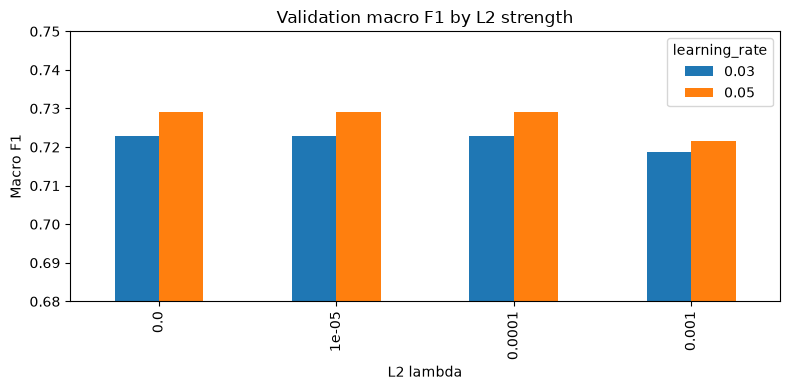

In [6]:
ax = runs.pivot(index='l2_lambda', columns='learning_rate', values='validation_macro_f1').sort_index().plot(kind='bar', figsize=(8,4), ylim=(0.68,0.75))
ax.set(title='Validation macro F1 by L2 strength', ylabel='Macro F1', xlabel='L2 lambda')
plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'a3_experiment_comparison.png', dpi=160)
plt.show()

In [7]:
model = joblib.load(ROOT / 'app' / 'models' / 'car_price_classifier.joblib')
pd.DataFrame(model.test_report_).T

,precision,recall,f1-score,support
0,0.844737,0.862903,0.853723,372.000000
1,0.647059,0.611111,0.628571,324.000000
2,0.624242,0.613095,0.618619,336.000000
3,0.817391,0.857143,0.836795,329.000000
accuracy,0.739897,0.739897,0.739897,0.739897
macro avg,0.733357,0.736063,0.734427,1361.000000
weighted avg,0.736632,0.739897,0.737990,1361.000000


The selected unregularised model (`lambda=0`, learning rate `0.05`) achieved **0.730 validation macro F1** and, after a full training refit, **0.740 test accuracy** and **0.734 test macro F1**. Small L2 values tied or nearly tied the winner; stronger L2 slightly underfit. The scratch and scikit-learn report values match numerically.

## 6. MLflow model registry and deployment

`training/train.py` sets tracking URI `http://mlflow.ml.brain.cs.ait.ac.th/`, experiment `st127314-a3`, logs parameters/metrics without logging the dataset, saves the final pipeline, and can register `st127314-a3-model` at Staging. Run:

```bash
python training/train.py --log-mlflow --register
```

The repository also contains the Dash application, Docker image, two model-interface unit tests, and a GitHub Actions workflow. Every push runs tests; a passing push builds and publishes the Docker image. Docker Hub credentials are stored as GitHub secrets, never in the repository.